## 1. Runtime and Configuration

The notebook uses TensorFlow with GPU acceleration and mixed-precision training.

Training is performed in two stages:

1. **Stage 1:** Train the new four-class classification layer while the EfficientNetV2B0 backbone remains frozen.
2. **Stage 2:** Continue from the best Stage 1 checkpoint and consider the final 40 backbone layers for fine-tuning while keeping Batch Normalization layers frozen.

Validation is used for checkpoint selection, early stopping, and learning-rate adjustment.

The Official Test split is not accessed and remains reserved for Notebook 4.

Main settings:

- Random seed: 42
- Mixed-precision policy: `float32`
- Input size: 224 × 224 × 3
- Batch size: 32
- Class order: Cat, Dog, Bird, Unknown
- Development model directory: `Model Building/Models/Development`
- Final model directory: `Model Building/Models/Final`
- Training results directory: `Model Building/Training Results`

In [1]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["TF_DETERMINISTIC_OPS"] = "1"

import json
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, mixed_precision


SEED = 42


gpus = tf.config.list_physical_devices("GPU")

if not gpus:
    raise RuntimeError(
        "No GPU detected. Select the Python "
        "(Image Classifier GPU) kernel."
    )

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(
            gpu,
            True,
        )
    except RuntimeError:
        pass


tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()
tf.config.experimental.enable_tensor_float_32_execution(
    False
)

mixed_precision.set_global_policy(
    "float32"
)


NOTEBOOK_DIR = Path.cwd()
MODEL_BUILDING_DIR = NOTEBOOK_DIR.parent

FINAL_DATASET_DIR = (
    MODEL_BUILDING_DIR
    / "Datasets"
    / "Final Dataset"
)

TRAIN_DIR = FINAL_DATASET_DIR / "Train"
VALIDATION_DIR = FINAL_DATASET_DIR / "Validation"

MODELS_DIR = MODEL_BUILDING_DIR / "Models"

DEVELOPMENT_MODELS_DIR = (
    MODELS_DIR
    / "Development"
)

FINAL_MODELS_DIR = (
    MODELS_DIR
    / "Final"
)

RESULTS_DIR = (
    MODEL_BUILDING_DIR
    / "Training Results"
)


output_directories = [
    DEVELOPMENT_MODELS_DIR,
    FINAL_MODELS_DIR,
    RESULTS_DIR,
]

for directory in output_directories:
    if directory.exists() and not directory.is_dir():
        raise FileExistsError(
            f"'{directory.name}' exists but is not a folder."
        )

    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


for split_name, split_directory in {
    "Train": TRAIN_DIR,
    "Validation": VALIDATION_DIR,
}.items():
    if not split_directory.is_dir():
        raise FileNotFoundError(
            f"{split_name} directory was not found."
        )


CLASS_NAMES = [
    "Cat",
    "Dog",
    "Bird",
    "Unknown",
]

NUM_CLASSES = len(CLASS_NAMES)

IMAGE_SIZE = (224, 224)
INPUT_SHAPE = (224, 224, 3)
BATCH_SIZE = 32
DROPOUT_RATE = 0.30


STAGE_1_LEARNING_RATE = 1e-3
STAGE_1_EPOCHS = 12
STAGE_1_PATIENCE = 3
STAGE_1_MIN_LEARNING_RATE = 1e-6

STAGE_2_LEARNING_RATE = 1e-5
STAGE_2_EPOCHS = 15
STAGE_2_PATIENCE = 4
STAGE_2_MIN_LEARNING_RATE = 1e-7

REDUCE_LR_FACTOR = 0.2
REDUCE_LR_PATIENCE = 2
FINE_TUNE_LAYERS = 40


STAGE_1_MODEL_PATH = (
    DEVELOPMENT_MODELS_DIR
    / "best_stage_1.keras"
)

STAGE_2_MODEL_PATH = (
    DEVELOPMENT_MODELS_DIR
    / "best_fine_tuned.keras"
)

FINAL_MODEL_PATH = (
    FINAL_MODELS_DIR
    / "cat_dog_bird_unknown.keras"
)


STAGE_1_HISTORY_PATH = (
    RESULTS_DIR
    / "stage_1_history.csv"
)

STAGE_2_HISTORY_PATH = (
    RESULTS_DIR
    / "stage_2_history.csv"
)

TRAINING_HISTORY_PLOT_PATH = (
    RESULTS_DIR
    / "training_history.png"
)

STAGE_1_ARCHITECTURE_PATH = (
    RESULTS_DIR
    / "model_architecture_stage_1.png"
)

STAGE_2_ARCHITECTURE_PATH = (
    RESULTS_DIR
    / "model_architecture_stage_2.png"
)

FINAL_CONFIGURATION_PATH = (
    RESULTS_DIR
    / "final_configuration.json"
)


gpu_details = (
    tf.config.experimental.get_device_details(
        gpus[0]
    )
)

print("TensorFlow:", tf.__version__)

print(
    "GPU:",
    gpu_details.get(
        "device_name",
        "Unknown",
    ),
)

print(
    "Mixed precision:",
    mixed_precision.global_policy(),
)

print("Random seed:", SEED)
print("Deterministic operations: Enabled")
print("oneDNN custom operations: Disabled")
print("TensorFloat-32 execution: Disabled")
print("Configuration ready.")

TensorFlow: 2.21.0
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
Random seed: 42
Deterministic operations: Enabled
oneDNN custom operations: Disabled
TensorFloat-32 execution: Disabled
Configuration ready.


## 2. Final Dataset Decode Verification

Before the dataset pipelines are created, every image in the final Train and Validation splits is checked using TensorFlow’s image decoder.

This verification identifies malformed files that may have passed earlier cleaning checks but cannot be decoded by the TensorFlow training pipeline.

The verification:

- Checks all supported image files in Train and Validation.
- Uses the same TensorFlow decoding process used during model training.
- Records native decoder warnings in `Model Building/Training Results/invalid_image_scan_warnings.log`.
- Reports every file that cannot be decoded successfully.
- Stops the notebook if invalid images are found.
- Allows training to continue only when all remaining images pass the decode check.

In [2]:
import sys
from contextlib import contextmanager

from tqdm import tqdm


@contextmanager
def capture_native_stderr(log_path):
    saved_stderr = os.dup(2)

    try:
        with open(
            log_path,
            "ab",
            buffering=0,
        ) as log_file:
            os.dup2(
                log_file.fileno(),
                2,
            )

            yield

    finally:
        os.dup2(
            saved_stderr,
            2,
        )

        os.close(
            saved_stderr
        )


IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".gif",
}


INVALID_IMAGE_SCAN_WARNINGS_PATH = (
    RESULTS_DIR
    / "invalid_image_scan_warnings.log"
)

if INVALID_IMAGE_SCAN_WARNINGS_PATH.exists():
    INVALID_IMAGE_SCAN_WARNINGS_PATH.unlink()


split_directories = {
    "Train": TRAIN_DIR,
    "Validation": VALIDATION_DIR,
}


images_to_check = []

for split_name, split_directory in split_directories.items():
    image_paths = sorted(
        path
        for path in split_directory.rglob("*")
        if (
            path.is_file()
            and path.suffix.lower() in IMAGE_EXTENSIONS
        )
    )

    images_to_check.extend(
        (split_name, image_path)
        for image_path in image_paths
    )


invalid_images = []


with capture_native_stderr(
    INVALID_IMAGE_SCAN_WARNINGS_PATH
):
    for split_name, image_path in tqdm(
        images_to_check,
        desc="TensorFlow decode check",
        unit="image",
        file=sys.stdout,
    ):
        try:
            image_bytes = tf.io.read_file(
                str(image_path)
            )

            image = tf.io.decode_image(
                image_bytes,
                channels=3,
                expand_animations=False,
            )

            image.set_shape(
                [None, None, 3]
            )

            height = int(
                tf.shape(image)[0].numpy()
            )

            width = int(
                tf.shape(image)[1].numpy()
            )

            if height <= 0 or width <= 0:
                raise ValueError(
                    "Decoded image has invalid dimensions."
                )

        except Exception as error:
            error_lines = [
                line.strip()
                for line in str(error).splitlines()
                if line.strip()
            ]

            error_message = next(
                (
                    line
                    for line in error_lines
                    if (
                        "Input size should match" in line
                        or "INVALID_ARGUMENT" in line
                    )
                ),
                (
                    error_lines[0]
                    if error_lines
                    else type(error).__name__
                ),
            )

            invalid_images.append(
                {
                    "split": split_name,
                    "path": image_path,
                    "error": error_message,
                }
            )


print()
print(
    "Images checked:",
    f"{len(images_to_check):,}",
)

print(
    "Invalid images:",
    f"{len(invalid_images):,}",
)


if invalid_images:
    print("\nInvalid image files")

    for invalid_image in invalid_images:
        relative_path = (
            invalid_image["path"]
            .relative_to(MODEL_BUILDING_DIR)
        )

        print()
        print(
            "Split:",
            invalid_image["split"],
        )

        print(
            "File:",
            relative_path,
        )

        print(
            "Error:",
            invalid_image["error"],
        )

    raise RuntimeError(
        f"{len(invalid_images):,} invalid image(s) found. "
        "Remove them and rerun this verification "
        "before creating the dataset pipelines."
    )


print(
    "All Train and Validation images passed "
    "TensorFlow decode verification."
)

if (
    INVALID_IMAGE_SCAN_WARNINGS_PATH.exists()
    and INVALID_IMAGE_SCAN_WARNINGS_PATH.stat().st_size > 0
):
    print(
        "Native decoder warnings saved to "
        "invalid_image_scan_warnings.log."
    )

TensorFlow decode check: 100%|██████████████████████████████████████████████| 146997/146997 [36:28<00:00, 67.16image/s]

Images checked: 146,997
Invalid images: 0
All Train and Validation images passed TensorFlow decode verification.
Native decoder warnings saved to invalid_image_scan_warnings.log.


## 3. Dataset Pipelines

Train and Validation use the same RGB input size, categorical labels, and padded resizing.

- Train is shuffled using random seed 42. The image order changes between epochs while remaining reproducible across equivalent runs.
- Validation is not shuffled so predictions remain aligned with the correct labels.
- Shuffling changes only the order in which training images are processed. It does not move or reassign files between dataset splits.
- The dataset pipelines are created once, while image batches are loaded as needed and prefetched for training efficiency.
- Pixel values remain in the range `[0,255]` because EfficientNetV2B0 performs its preprocessing internally.

In [3]:
AUTOTUNE = tf.data.AUTOTUNE


train_dataset = (
    tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR,
        label_mode="categorical",
        class_names=CLASS_NAMES,
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED,
        interpolation="bilinear",
        pad_to_aspect_ratio=True,
    )
)


validation_dataset = (
    tf.keras.utils.image_dataset_from_directory(
        VALIDATION_DIR,
        label_mode="categorical",
        class_names=CLASS_NAMES,
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False,
        interpolation="bilinear",
        pad_to_aspect_ratio=True,
    )
)


dataset_options = tf.data.Options()
dataset_options.deterministic = True


train_dataset = train_dataset.with_options(
    dataset_options
)

validation_dataset = validation_dataset.with_options(
    dataset_options
)


train_dataset = train_dataset.prefetch(
    AUTOTUNE
)

validation_dataset = validation_dataset.prefetch(
    AUTOTUNE
)


print("Train pipeline ready.")
print("Validation pipeline ready.")
print("Deterministic dataset order: Enabled")

Found 132306 files belonging to 4 classes.
Found 14691 files belonging to 4 classes.
Train pipeline ready.
Validation pipeline ready.
Deterministic dataset order: Enabled


## 4. Stage 1 Model Architecture

Stage 1 uses EfficientNetV2B0 with ImageNet pretrained weights and its original classification head removed. The backbone’s built-in input preprocessing remains enabled.

Moderate augmentation is applied only during training:

- Horizontal flipping
- Rotation: 0.03
- Translation: 0.05
- Zoom: 0.10
- Contrast: 0.10

The Stage 1 model structure is:

```text
224 × 224 × 3 RGB input
→ Training-only data augmentation
→ Frozen EfficientNetV2B0 backbone
→ GlobalAveragePooling2D
→ Dropout(0.30)
→ Dense(4, softmax)
→ Cat, Dog, Bird, Unknown

In [4]:
tf.keras.backend.clear_session()


data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip(
            "horizontal",
            seed=SEED,
        ),
        layers.RandomRotation(
            0.03,
            seed=SEED + 1,
        ),
        layers.RandomTranslation(
            0.05,
            0.05,
            seed=SEED + 2,
        ),
        layers.RandomZoom(
            0.10,
            seed=SEED + 3,
        ),
        layers.RandomContrast(
            0.10,
            seed=SEED + 4,
        ),
    ],
    name="data_augmentation",
)


def create_metrics():
    return [
        tf.keras.metrics.CategoricalAccuracy(
            name="accuracy",
        ),
        tf.keras.metrics.F1Score(
            average="macro",
            name="macro_f1",
        ),
        tf.keras.metrics.Recall(
            top_k=1,
            class_id=0,
            name="cat_recall",
        ),
        tf.keras.metrics.Recall(
            top_k=1,
            class_id=1,
            name="dog_recall",
        ),
        tf.keras.metrics.Recall(
            top_k=1,
            class_id=2,
            name="bird_recall",
        ),
        tf.keras.metrics.Recall(
            top_k=1,
            class_id=3,
            name="unknown_recall",
        ),
    ]


backbone = tf.keras.applications.EfficientNetV2B0(
    weights="imagenet",
    include_top=False,
    include_preprocessing=True,
    input_shape=INPUT_SHAPE,
)

backbone.trainable = False


inputs = layers.Input(
    shape=INPUT_SHAPE,
    name="image_input",
)

x = data_augmentation(
    inputs
)

x = backbone(
    x,
    training=False,
)

x = layers.GlobalAveragePooling2D(
    name="global_average_pooling",
)(x)

x = layers.Dropout(
    DROPOUT_RATE,
    name="dropout",
)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    dtype="float32",
    name="predictions",
)(x)


model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="cat_dog_bird_unknown_classifier",
)


model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=STAGE_1_LEARNING_RATE,
        clipnorm=1.0,
    ),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=create_metrics(),
)


model.summary()


try:
    tf.keras.utils.plot_model(
        model,
        to_file=str(
            STAGE_1_ARCHITECTURE_PATH
        ),
        show_shapes=True,
        show_layer_names=True,
        show_trainable=True,
        expand_nested=False,
        splines="polyline",
        dpi=96,
    )

    print(
        "Stage 1 architecture diagram saved."
    )

except Exception as error:
    print(
        "Stage 1 architecture diagram "
        "could not be generated."
    )
    print(
        "The model was still built and "
        "compiled successfully."
    )
    print(
        "Error:",
        error,
    )

Model: "cat_dog_bird_unknown_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,924,436 (22.60 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

Stage 1 architecture diagram saved.


## 5. Stage 1: Frozen Backbone Training

Stage 1 trains the new four-class classification head while the pretrained EfficientNetV2B0 backbone remains frozen.

Training settings:

- Learning rate: `1e-3`
- Maximum epochs: 12
- Optimizer: Adam with `clipnorm=1.0`
- Loss: categorical crossentropy
- Checkpoint metric: Validation macro F1
- Early-stopping patience: 3
- Learning-rate reduction factor: 0.2
- Learning-rate reduction patience: 2
- Minimum learning rate: `1e-6`

The checkpoint with the highest Validation macro F1 is saved as:

`Model Building/Models/Development/best_stage_1.keras`

In [5]:
STAGE_1_WARNINGS_PATH = (
    RESULTS_DIR
    / "stage_1_warnings.log"
)

if STAGE_1_WARNINGS_PATH.exists():
    STAGE_1_WARNINGS_PATH.unlink()


stage_1_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(STAGE_1_MODEL_PATH),
        monitor="val_macro_f1",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_macro_f1",
        mode="max",
        patience=STAGE_1_PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=REDUCE_LR_FACTOR,
        patience=REDUCE_LR_PATIENCE,
        min_lr=STAGE_1_MIN_LEARNING_RATE,
        verbose=1,
    ),
    tf.keras.callbacks.CSVLogger(
        filename=str(STAGE_1_HISTORY_PATH),
        append=False,
    ),
]


with capture_native_stderr(
    STAGE_1_WARNINGS_PATH
):
    stage_1_history = model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=STAGE_1_EPOCHS,
        callbacks=stage_1_callbacks,
        shuffle=False,
    )


best_stage_1_index = int(
    np.argmax(
        stage_1_history.history["val_macro_f1"]
    )
)

best_stage_1_epoch = best_stage_1_index + 1

stage_1_epochs_completed = len(
    stage_1_history.history["loss"]
)


best_stage_1_macro_f1 = float(
    stage_1_history.history["val_macro_f1"][
        best_stage_1_index
    ]
)

best_stage_1_accuracy = float(
    stage_1_history.history["val_accuracy"][
        best_stage_1_index
    ]
)

best_stage_1_loss = float(
    stage_1_history.history["val_loss"][
        best_stage_1_index
    ]
)

best_stage_1_cat_recall = float(
    stage_1_history.history["val_cat_recall"][
        best_stage_1_index
    ]
)

best_stage_1_dog_recall = float(
    stage_1_history.history["val_dog_recall"][
        best_stage_1_index
    ]
)

best_stage_1_bird_recall = float(
    stage_1_history.history["val_bird_recall"][
        best_stage_1_index
    ]
)

best_stage_1_unknown_recall = float(
    stage_1_history.history["val_unknown_recall"][
        best_stage_1_index
    ]
)


print(
    "Epochs completed:",
    stage_1_epochs_completed,
)

print(
    "Best Stage 1 epoch:",
    best_stage_1_epoch,
)

print(
    "Validation accuracy:",
    f"{best_stage_1_accuracy:.4f}",
)

print(
    "Validation macro F1:",
    f"{best_stage_1_macro_f1:.4f}",
)

print(
    "Validation loss:",
    f"{best_stage_1_loss:.4f}",
)

print(
    "Cat recall:",
    f"{best_stage_1_cat_recall:.4f}",
)

print(
    "Dog recall:",
    f"{best_stage_1_dog_recall:.4f}",
)

print(
    "Bird recall:",
    f"{best_stage_1_bird_recall:.4f}",
)

print(
    "Unknown recall:",
    f"{best_stage_1_unknown_recall:.4f}",
)

print("Best Stage 1 checkpoint saved.")
print("Stage 1 training history saved.")


if (
    STAGE_1_WARNINGS_PATH.exists()
    and STAGE_1_WARNINGS_PATH.stat().st_size > 0
):
    print(
        "Native Stage 1 warnings saved to "
        "stage_1_warnings.log."
    )

Epoch 1/12
4135/4135 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9627 - bird_recall: 0.9568 - cat_recall: 0.9689 - dog_recall: 0.9663 - loss: 0.1242 - macro_f1: 0.9636 - unknown_recall: 0.9605
Epoch 1: val_macro_f1 improved from None to 0.97506, saving model to /mnt/c/Users/uushu/Desktop/Image Classifier Project/Model Building/Models/Development/best_stage_1.keras

Epoch 1: finished saving model to /mnt/c/Users/uushu/Desktop/Image Classifier Project/Model Building/Models/Development/best_stage_1.keras
4135/4135 ━━━━━━━━━━━━━━━━━━━━ 342s 81ms/step - accuracy: 0.9627 - bird_recall: 0.9568 - cat_recall: 0.9689 - dog_recall: 0.9663 - loss: 0.1242 - macro_f1: 0.9636 - unknown_recall: 0.9605 - val_accuracy: 0.9740 - val_bird_recall: 0.9893 - val_cat_recall: 0.9911 - val_dog_recall: 0.9942 - val_loss: 0.0960 - val_macro_f1: 0.9751 - val_unknown_recall: 0.9445 - learning_rate: 0.0010
Epoch 2/12
4134/4135 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9699 - bird_recall: 0.9625 - cat_recal

## 6. Stage 2: Fine-Tuning

Stage 2 loads the best Stage 1 checkpoint and enables the EfficientNetV2B0 backbone for fine-tuning.

Only the final 40 backbone layers are considered. Batch Normalization layers remain frozen, while the other selected layers become trainable.

The same training-only augmentation remains active, and Validation images are evaluated without augmentation.

Training settings:

- Learning rate: `1e-5`
- Maximum epochs: 15
- Optimizer: Adam with `clipnorm=1.0`
- Loss: categorical crossentropy
- Checkpoint metric: Validation macro F1
- Early-stopping patience: 4
- Learning-rate reduction factor: 0.2
- Learning-rate reduction patience: 2
- Minimum learning rate: `1e-7`

The code prints the updated parameter counts, generates the Stage 2 architecture diagram, trains the model, saves the best checkpoint, records the training history, and prints the results from the best epoch.

Outputs:

- `Model Building/Training Results/model_architecture_stage_2.png`
- `Model Building/Models/Development/best_fine_tuned.keras`
- `Model Building/Training Results/stage_2_history.csv`

In [6]:
if not STAGE_1_MODEL_PATH.is_file():
    raise FileNotFoundError(
        "The best Stage 1 checkpoint was not found."
    )


tf.keras.backend.clear_session()


fine_tuned_model = tf.keras.models.load_model(
    STAGE_1_MODEL_PATH,
    compile=False,
)

fine_tuned_backbone = fine_tuned_model.get_layer(
    "efficientnetv2-b0"
)


fine_tuned_backbone.trainable = True

for layer in fine_tuned_backbone.layers:
    layer.trainable = False

for layer in fine_tuned_backbone.layers[
    -FINE_TUNE_LAYERS:
]:
    if isinstance(
        layer,
        layers.BatchNormalization,
    ):
        layer.trainable = False
    else:
        layer.trainable = True


fine_tuned_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=STAGE_2_LEARNING_RATE,
        clipnorm=1.0,
    ),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=create_metrics(),
)


total_parameters = fine_tuned_model.count_params()

trainable_parameters = int(
    sum(
        tf.keras.backend.count_params(weight)
        for weight in fine_tuned_model.trainable_weights
    )
)

non_trainable_parameters = (
    total_parameters - trainable_parameters
)

trainable_backbone_layers = sum(
    1
    for layer in fine_tuned_backbone.layers
    if layer.trainable
)

frozen_batch_normalization_layers = sum(
    1
    for layer in fine_tuned_backbone.layers[
        -FINE_TUNE_LAYERS:
    ]
    if isinstance(
        layer,
        layers.BatchNormalization,
    )
)


print(
    "Backbone layers:",
    len(fine_tuned_backbone.layers),
)

print(
    "Final layers considered:",
    FINE_TUNE_LAYERS,
)

print(
    "Trainable backbone layers:",
    trainable_backbone_layers,
)

print(
    "Frozen Batch Normalization layers "
    "within final 40:",
    frozen_batch_normalization_layers,
)

print(
    "Total parameters:",
    f"{total_parameters:,}",
)

print(
    "Trainable parameters:",
    f"{trainable_parameters:,}",
)

print(
    "Non-trainable parameters:",
    f"{non_trainable_parameters:,}",
)


fine_tuned_model.summary()


try:
    tf.keras.utils.plot_model(
        fine_tuned_model,
        to_file=str(
            STAGE_2_ARCHITECTURE_PATH
        ),
        show_shapes=True,
        show_layer_names=True,
        show_trainable=True,
        expand_nested=False,
        splines="polyline",
        dpi=96,
    )

    print(
        "Stage 2 architecture diagram saved."
    )

except Exception as error:
    print(
        "Stage 2 architecture diagram "
        "could not be generated."
    )

    print(
        "The model was still configured "
        "and compiled successfully."
    )

    print(
        "Error:",
        error,
    )


STAGE_2_WARNINGS_PATH = (
    RESULTS_DIR
    / "stage_2_warnings.log"
)

if STAGE_2_WARNINGS_PATH.exists():
    STAGE_2_WARNINGS_PATH.unlink()


stage_2_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(STAGE_2_MODEL_PATH),
        monitor="val_macro_f1",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_macro_f1",
        mode="max",
        patience=STAGE_2_PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=REDUCE_LR_FACTOR,
        patience=REDUCE_LR_PATIENCE,
        min_lr=STAGE_2_MIN_LEARNING_RATE,
        verbose=1,
    ),
    tf.keras.callbacks.CSVLogger(
        filename=str(STAGE_2_HISTORY_PATH),
        append=False,
    ),
]


with capture_native_stderr(
    STAGE_2_WARNINGS_PATH
):
    stage_2_history = fine_tuned_model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=STAGE_2_EPOCHS,
        callbacks=stage_2_callbacks,
        shuffle=False,
    )


best_stage_2_index = int(
    np.argmax(
        stage_2_history.history["val_macro_f1"]
    )
)

best_stage_2_epoch = best_stage_2_index + 1

stage_2_epochs_completed = len(
    stage_2_history.history["loss"]
)


best_stage_2_macro_f1 = float(
    stage_2_history.history["val_macro_f1"][
        best_stage_2_index
    ]
)

best_stage_2_accuracy = float(
    stage_2_history.history["val_accuracy"][
        best_stage_2_index
    ]
)

best_stage_2_loss = float(
    stage_2_history.history["val_loss"][
        best_stage_2_index
    ]
)

best_stage_2_cat_recall = float(
    stage_2_history.history["val_cat_recall"][
        best_stage_2_index
    ]
)

best_stage_2_dog_recall = float(
    stage_2_history.history["val_dog_recall"][
        best_stage_2_index
    ]
)

best_stage_2_bird_recall = float(
    stage_2_history.history["val_bird_recall"][
        best_stage_2_index
    ]
)

best_stage_2_unknown_recall = float(
    stage_2_history.history[
        "val_unknown_recall"
    ][best_stage_2_index]
)


print(
    "Epochs completed:",
    stage_2_epochs_completed,
)

print(
    "Best Stage 2 epoch:",
    best_stage_2_epoch,
)

print(
    "Validation accuracy:",
    f"{best_stage_2_accuracy:.4f}",
)

print(
    "Validation macro F1:",
    f"{best_stage_2_macro_f1:.4f}",
)

print(
    "Validation loss:",
    f"{best_stage_2_loss:.4f}",
)

print(
    "Cat recall:",
    f"{best_stage_2_cat_recall:.4f}",
)

print(
    "Dog recall:",
    f"{best_stage_2_dog_recall:.4f}",
)

print(
    "Bird recall:",
    f"{best_stage_2_bird_recall:.4f}",
)

print(
    "Unknown recall:",
    f"{best_stage_2_unknown_recall:.4f}",
)

print("Best Stage 2 checkpoint saved.")
print("Stage 2 training history saved.")


if (
    STAGE_2_WARNINGS_PATH.exists()
    and STAGE_2_WARNINGS_PATH.stat().st_size > 0
):
    print(
        "Native Stage 2 warnings saved to "
        "stage_2_warnings.log."
    )

Backbone layers: 270
Final layers considered: 40
Trainable backbone layers: 32
Frozen Batch Normalization layers within final 40: 8
Total parameters: 5,924,436
Trainable parameters: 1,712,916
Non-trainable parameters: 4,211,520


Model: "cat_dog_bird_unknown_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,924,436 (22.60 MB)

 Trainable params: 1,712,916 (6.53 MB)

 Non-trainable params: 4,211,520 (16.07 MB)

Stage 2 architecture diagram saved.
Epoch 1/15
4135/4135 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9753 - bird_recall: 0.9662 - cat_recall: 0.9775 - dog_recall: 0.9779 - loss: 0.0757 - macro_f1: 0.9758 - unknown_recall: 0.9778
Epoch 1: val_macro_f1 improved from None to 0.98756, saving model to /mnt/c/Users/uushu/Desktop/Image Classifier Project/Model Building/Models/Development/best_fine_tuned.keras

Epoch 1: finished saving model to /mnt/c/Users/uushu/Desktop/Image Classifier Project/Model Building/Models/Development/best_fine_tuned.keras
4135/4135 ━━━━━━━━━━━━━━━━━━━━ 398s 94ms/step - accuracy: 0.9753 - bird_recall: 0.9662 - cat_recall: 0.9775 - dog_recall: 0.9779 - loss: 0.0757 - macro_f1: 0.9758 - unknown_recall: 0.9778 - val_accuracy: 0.9873 - val_bird_recall: 0.9877 - val_cat_recall: 0.9917 - val_dog_recall: 0.9926 - val_loss: 0.0416 - val_macro_f1: 0.9876 - val_unknown_recall: 0.9815 - learning_rate: 1.0000e-05
Epoch 2/15
4135/4135 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accu

## 7. Final Training Outputs

The Stage 1 and Stage 2 training histories are combined into one training-history figure showing categorical accuracy, macro F1, and loss for Train and Validation.

The best Stage 2 checkpoint is copied into the final model directory and reloaded to verify that it accepts `224 × 224 × 3` RGB inputs and produces four output probabilities in the fixed class order:

```text
Cat, Dog, Bird, Unknown
````

The final configuration is saved with the model settings, preprocessing method, class order, and output locations.


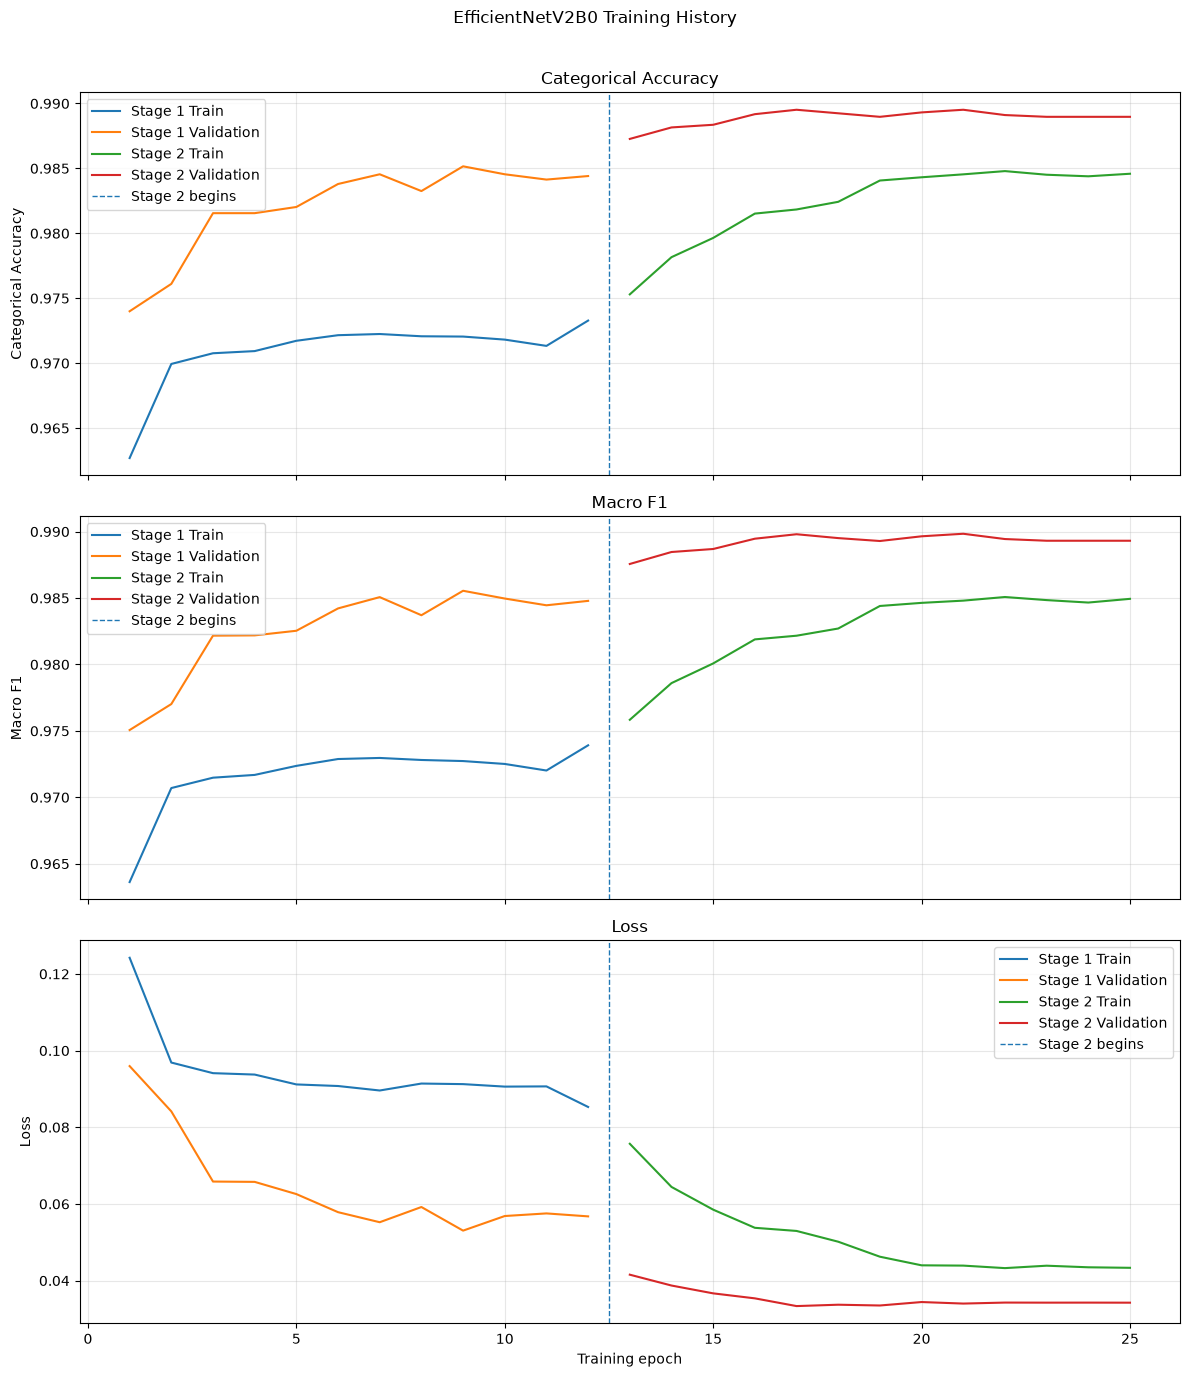

Final training outputs saved.
Final model: Model Building/Models/Final/cat_dog_bird_unknown.keras
Training history plot: Model Building/Training Results/training_history.png
Final configuration: Model Building/Training Results/final_configuration.json
Verified input shape: (None, 224, 224, 3)
Verified output classes: 4
Decision rule: Highest predicted probability (argmax)


In [8]:
# 7. Final Training Outputs

required_files = {
    "Stage 1 training history": STAGE_1_HISTORY_PATH,
    "Stage 2 training history": STAGE_2_HISTORY_PATH,
    "Best Stage 2 checkpoint": STAGE_2_MODEL_PATH,
}

for file_description, file_path in required_files.items():
    if not file_path.is_file():
        raise FileNotFoundError(
            f"{file_description} was not found."
        )


stage_1_history_frame = pd.read_csv(
    STAGE_1_HISTORY_PATH
)

stage_2_history_frame = pd.read_csv(
    STAGE_2_HISTORY_PATH
)


stage_1_plot_epochs = np.arange(
    1,
    len(stage_1_history_frame) + 1,
)

stage_2_plot_epochs = np.arange(
    len(stage_1_history_frame) + 1,
    len(stage_1_history_frame)
    + len(stage_2_history_frame)
    + 1,
)

stage_boundary = (
    len(stage_1_history_frame) + 0.5
)


figure, axes = plt.subplots(
    3,
    1,
    figsize=(12, 14),
    sharex=True,
)


plot_metrics = [
    (
        "Categorical Accuracy",
        "accuracy",
        "val_accuracy",
    ),
    (
        "Macro F1",
        "macro_f1",
        "val_macro_f1",
    ),
    (
        "Loss",
        "loss",
        "val_loss",
    ),
]


for axis, (
    metric_title,
    train_metric,
    validation_metric,
) in zip(
    axes,
    plot_metrics,
):
    axis.plot(
        stage_1_plot_epochs,
        stage_1_history_frame[train_metric],
        label="Stage 1 Train",
    )

    axis.plot(
        stage_1_plot_epochs,
        stage_1_history_frame[validation_metric],
        label="Stage 1 Validation",
    )

    axis.plot(
        stage_2_plot_epochs,
        stage_2_history_frame[train_metric],
        label="Stage 2 Train",
    )

    axis.plot(
        stage_2_plot_epochs,
        stage_2_history_frame[validation_metric],
        label="Stage 2 Validation",
    )

    axis.axvline(
        stage_boundary,
        linestyle="--",
        linewidth=1,
        label="Stage 2 begins",
    )

    axis.set_title(
        metric_title
    )

    axis.set_ylabel(
        metric_title
    )

    axis.grid(
        alpha=0.3
    )

    axis.legend()


axes[-1].set_xlabel(
    "Training epoch"
)

figure.suptitle(
    "EfficientNetV2B0 Training History"
)

figure.tight_layout(
    rect=(0, 0, 1, 0.97)
)

figure.savefig(
    TRAINING_HISTORY_PLOT_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

plt.close(
    figure
)


shutil.copy2(
    STAGE_2_MODEL_PATH,
    FINAL_MODEL_PATH,
)


final_model = tf.keras.models.load_model(
    FINAL_MODEL_PATH,
    compile=False,
)


if tuple(final_model.input_shape[1:]) != INPUT_SHAPE:
    raise RuntimeError(
        "The final model input shape is incorrect."
    )

if int(final_model.output_shape[-1]) != NUM_CLASSES:
    raise RuntimeError(
        "The final model output count is incorrect."
    )


final_total_parameters = (
    final_model.count_params()
)

final_trainable_parameters = int(
    sum(
        tf.keras.backend.count_params(weight)
        for weight in final_model.trainable_weights
    )
)

final_non_trainable_parameters = (
    final_total_parameters
    - final_trainable_parameters
)


def project_relative(path):
    return path.relative_to(
        MODEL_BUILDING_DIR.parent
    ).as_posix()


final_configuration = {
    "model": {
        "name": final_model.name,
        "architecture": "EfficientNetV2B0",
        "input_shape": list(INPUT_SHAPE),
        "class_names": CLASS_NAMES,
        "number_of_classes": NUM_CLASSES,
        "dropout_rate": DROPOUT_RATE,
        "total_parameters": final_total_parameters,
        "trainable_parameters": (
            final_trainable_parameters
        ),
        "non_trainable_parameters": (
            final_non_trainable_parameters
        ),
    },
    "preprocessing": {
        "colour_mode": "RGB",
        "resize_method": (
            "Bilinear aspect-ratio-preserving "
            "resize with padding"
        ),
        "input_size": list(IMAGE_SIZE),
        "input_pixel_range": "[0,255]",
        "efficientnet_preprocessing": (
            "Included inside the model"
        ),
    },
    "prediction": {
        "decision_rule": (
            "Highest predicted probability (argmax)"
        ),
        "class_order": CLASS_NAMES,
        "unknown": (
            "A directly trained fourth class"
        ),
    },
    "training": {
        "random_seed": SEED,
        "mixed_precision_policy": (
            mixed_precision.global_policy().name
        ),
        "batch_size": BATCH_SIZE,
        "optimizer": "Adam",
        "loss": "Categorical crossentropy",
        "gradient_clipnorm": 1.0,
        "checkpoint_metric": (
            "Validation macro F1"
        ),
        "stage_1": {
            "backbone": "Frozen",
            "learning_rate": (
                STAGE_1_LEARNING_RATE
            ),
            "maximum_epochs": STAGE_1_EPOCHS,
            "early_stopping_patience": (
                STAGE_1_PATIENCE
            ),
        },
        "stage_2": {
            "final_backbone_layers_considered": (
                FINE_TUNE_LAYERS
            ),
            "batch_normalization": "Frozen",
            "learning_rate": (
                STAGE_2_LEARNING_RATE
            ),
            "maximum_epochs": STAGE_2_EPOCHS,
            "early_stopping_patience": (
                STAGE_2_PATIENCE
            ),
        },
    },
    "files": {
        "source_checkpoint": project_relative(
            STAGE_2_MODEL_PATH
        ),
        "final_model": project_relative(
            FINAL_MODEL_PATH
        ),
        "training_history_plot": project_relative(
            TRAINING_HISTORY_PLOT_PATH
        ),
    },
}


with open(
    FINAL_CONFIGURATION_PATH,
    "w",
    encoding="utf-8",
) as configuration_file:
    json.dump(
        final_configuration,
        configuration_file,
        indent=4,
    )


print("Final training outputs saved.")

print(
    "Final model:",
    project_relative(
        FINAL_MODEL_PATH
    ),
)

print(
    "Training history plot:",
    project_relative(
        TRAINING_HISTORY_PLOT_PATH
    ),
)

print(
    "Final configuration:",
    project_relative(
        FINAL_CONFIGURATION_PATH
    ),
)

print(
    "Verified input shape:",
    final_model.input_shape,
)

print(
    "Verified output classes:",
    final_model.output_shape[-1],
)

print(
    "Decision rule: Highest predicted "
    "probability (argmax)"
)